# Transfer learning 
## Clasificación de imagénes

En este cuaderno se implementa Transfer Learning sobre clasificación de imagenes absados en 

In [7]:
# Instalar tensorflow_hub con: pip install tensorflow_hub
# Instalar opencv-python con: pip install opencv-python
# Instalar matplotlib con: pip install matplotlib
# Instalar tf-keras con: pip install tf-keras

In [2]:
import numpy as np
import cv2

import PIL.Image as Image
import os

import matplotlib.pylab as plt

import tensorflow as tf
import tensorflow_hub as hub

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

/Users/patricio/Documents/github/Cienciadedatos/.venv/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
/Users/patricio/Documents/github/Cienciadedatos/.venv/lib/python3.13/site-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


**Realizar una prediccion con el modelo sin entrenamiento previo**

In [3]:

import tf_keras as keras

IMAGE_SHAPE = (224, 224) # Tamaño de imagen requerido por MobileNetV2 (alto, ancho)

classifier = keras.Sequential([
    hub.KerasLayer(
        "https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/4",
        input_shape=IMAGE_SHAPE + (3,)
    )
])

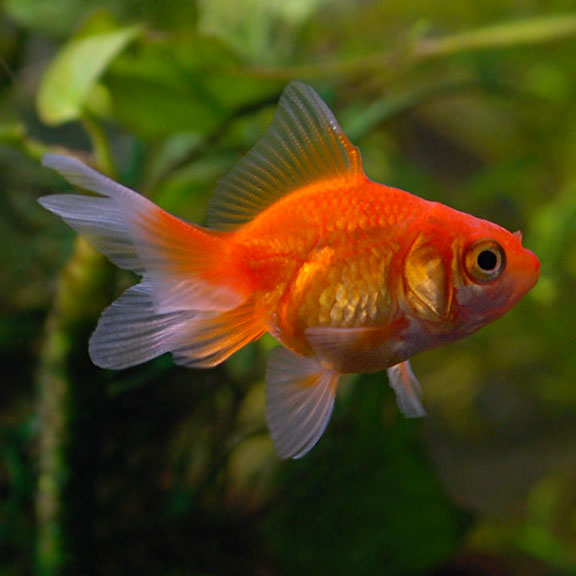

In [4]:
gold_fish = Image.open("goldfish.jpg")
gold_fish

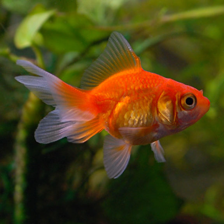

In [5]:
gold_fish = Image.open("goldfish.jpg").resize(IMAGE_SHAPE)
gold_fish

In [6]:
gold_fish = np.array(gold_fish)/255.0 # Normalizar los valores de píxeles a [0, 1]
gold_fish.shape

(224, 224, 3)

In [ ]:
# El modelo espera un lote de imágenes, así que añadimos una dimensión extra 
# para representar el tamaño del lote (en este caso, 1 imagen)
gold_fish[np.newaxis, ...]

array([[[[0.28235294, 0.33333333, 0.07058824],
         [0.31372549, 0.37254902, 0.09019608],
         [0.34901961, 0.41960784, 0.11764706],
         ...,
         [0.32941176, 0.39215686, 0.00392157],
         [0.32156863, 0.38431373, 0.00392157],
         [0.30980392, 0.36862745, 0.        ]],

        [[0.28627451, 0.33333333, 0.08235294],
         [0.3254902 , 0.38039216, 0.10980392],
         [0.35294118, 0.42352941, 0.12941176],
         ...,
         [0.32156863, 0.38039216, 0.00392157],
         [0.31372549, 0.37254902, 0.00392157],
         [0.30196078, 0.36078431, 0.        ]],

        [[0.28627451, 0.33333333, 0.08627451],
         [0.31372549, 0.36862745, 0.10196078],
         [0.34509804, 0.41568627, 0.12941176],
         ...,
         [0.31764706, 0.37647059, 0.00392157],
         [0.30980392, 0.36862745, 0.00784314],
         [0.29803922, 0.35686275, 0.00392157]],

        ...,

        [[0.05490196, 0.10980392, 0.01568627],
         [0.05098039, 0.11372549, 0.01960784]

In [8]:
result = classifier.predict(gold_fish[np.newaxis, ...])
result.shape

1/1 [==============================] - 0s 178ms/step


(1, 1001)

In [9]:
predicted_label_index = np.argmax(result)
predicted_label_index

np.int64(2)

In [ ]:
# lectura de las etiquetas de imagen de ImageNet
tf.keras.utils.get_file('ImageNetLabels.txt','https://storage.googleapis.com/download.tensorflow.org/data/ImageNetLabels.txt')
image_labels = []
with open("ImageNetLabels.txt", "r") as f:
    image_labels = f.read().splitlines()
image_labels[:5]

['background', 'tench', 'goldfish', 'great white shark', 'tiger shark']

In [11]:
image_labels[predicted_label_index]

'goldfish'

### Cargar el dataset de flores

In [12]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)
# cache_dir indicates where to download data. I specified . which means current directory
# untar true will unzip it
#data_dir = os.path.join(os.path.dirname(data_dir), 'flower_photos')

In [13]:
data_dir = os.path.join(os.path.dirname(data_dir), 'flower_photos/flower_photos')
data_dir

'./datasets/flower_photos/flower_photos'

In [14]:
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

PosixPath('datasets/flower_photos/flower_photos')

In [15]:
list(data_dir.glob('*/*.jpg'))[:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/16209331331_343c899d38.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/5777669976_a205f61e5b.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/4860145119_b1c3cbaa4e_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/15011625580_7974c44bce.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/17953368844_be3d18cf30_m.jpg')]

In [16]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

3670


In [17]:
roses = list(data_dir.glob('roses/*'))
roses[:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/16209331331_343c899d38.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/5777669976_a205f61e5b.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/4860145119_b1c3cbaa4e_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/15011625580_7974c44bce.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/17953368844_be3d18cf30_m.jpg')]

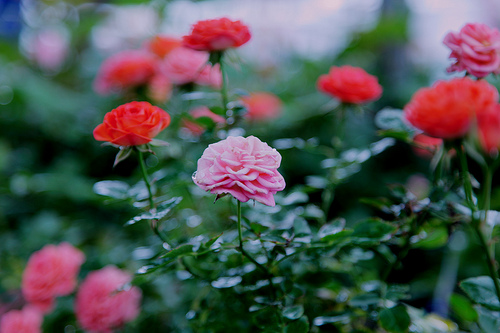

In [18]:
Image.open(str(roses[1]))

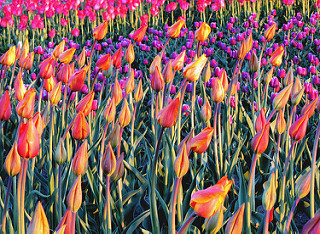

In [19]:
tulips = list(data_dir.glob('tulips/*'))
Image.open(str(tulips[0]))

### Leer las imagenes de flores a un array numpy mediante opencv

In [20]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

In [21]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [22]:
flowers_images_dict['roses'][:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/16209331331_343c899d38.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/5777669976_a205f61e5b.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/4860145119_b1c3cbaa4e_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/15011625580_7974c44bce.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/17953368844_be3d18cf30_m.jpg')]

In [23]:
str(flowers_images_dict['roses'][0])

'datasets/flower_photos/flower_photos/roses/16209331331_343c899d38.jpg'

In [24]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))
img.shape

(243, 500, 3)

In [25]:
# MobileNetV2 requiere imágenes de tamaño 224x224 píxeles
cv2.resize(img,(224,224)).shape

(224, 224, 3)

In [26]:
# Crear listas para almacenar las imágenes y sus etiquetas correspondientes
X, y = [], []

for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(224,224))
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [27]:
# Convertir las listas a arrays de NumPy
X = np.array(X)
y = np.array(y)

<h3 style='color:purple'>Train test split</h3>

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

<h3 style='color:purple'>Preprocessing: scale images</h3>

In [29]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

**Make prediction using pre-trained model on new flowers dataset**

In [30]:
X[0].shape

(224, 224, 3)

In [31]:
IMAGE_SHAPE+(3,)

(224, 224, 3)

In [32]:
x0_resized = cv2.resize(X[0], IMAGE_SHAPE)
x1_resized = cv2.resize(X[1], IMAGE_SHAPE)
x2_resized = cv2.resize(X[2], IMAGE_SHAPE)

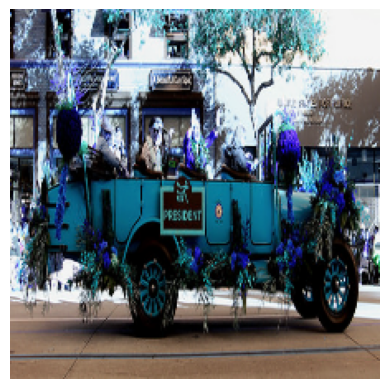

In [33]:
plt.axis('off')
plt.imshow(X[0])

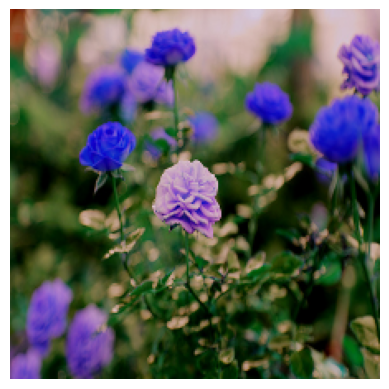

In [34]:
plt.axis('off')
plt.imshow(X[1])

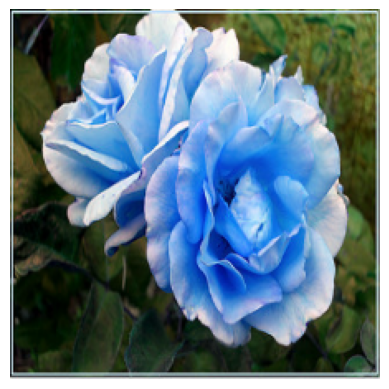

In [35]:
plt.axis('off')
plt.imshow(X[2])

In [36]:
predicted = classifier.predict(np.array([x0_resized, x1_resized, x2_resized]))
predicted = np.argmax(predicted, axis=1)
predicted

1/1 [==============================] - 0s 180ms/step


array([795, 795, 722])

In [37]:
image_labels[795]

'shower curtain'

In [42]:
image_labels[722]

'pillow'

<h3>Tomar modelo preentrenado usando las imagenes de flores </h3>

In [38]:
# Descargar el modelo preentrenado MobileNetV2 sin la capa de clasificación superior
feature_extractor_model = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"

pretrained_model_without_top_layer = hub.KerasLayer(
    feature_extractor_model, input_shape=(224, 224, 3), trainable=False)

In [39]:
# Construir un nuevo modelo añadiendo una capa densa de clasificación al modelo preentrenado
import tf_keras as keras
num_of_flowers = 5

model = keras.Sequential([
  pretrained_model_without_top_layer,
  keras.layers.Dense(num_of_flowers)
])

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_1 (KerasLayer)  (None, 1280)              2257984   
                                                                 
 dense (Dense)               (None, 5)                 6405      
                                                                 
Total params: 2264389 (8.64 MB)
Trainable params: 6405 (25.02 KB)
Non-trainable params: 2257984 (8.61 MB)
_________________________________________________________________


In [44]:
# Compilar el modelo con un optimizador, una función de pérdida y métricas
model.compile(
  optimizer="adam",
  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['acc'])

model.fit(X_train_scaled, y_train, epochs=15)

Epoch 1/15
86/86 [==============================] - 15s 161ms/step - loss: 0.2164 - acc: 0.9339
Epoch 2/15
86/86 [==============================] - 14s 158ms/step - loss: 0.1792 - acc: 0.9469
Epoch 3/15
86/86 [==============================] - 13s 154ms/step - loss: 0.1534 - acc: 0.9593
Epoch 4/15
86/86 [==============================] - 14s 162ms/step - loss: 0.1341 - acc: 0.9680
Epoch 5/15
86/86 [==============================] - 15s 171ms/step - loss: 0.1178 - acc: 0.9727
Epoch 6/15
86/86 [==============================] - 13s 156ms/step - loss: 0.1034 - acc: 0.9822
Epoch 7/15
86/86 [==============================] - 13s 157ms/step - loss: 0.0964 - acc: 0.9833
Epoch 8/15
86/86 [==============================] - 13s 154ms/step - loss: 0.0846 - acc: 0.9898
Epoch 9/15
86/86 [==============================] - 14s 162ms/step - loss: 0.0751 - acc: 0.9916
Epoch 10/15
86/86 [==============================] - 13s 156ms/step - loss: 0.0694 - acc: 0.9935
Epoch 11/15
86/86 [====================

In [45]:
# Evaluar el modelo en el conjunto de prueba
model.evaluate(X_test_scaled,y_test)

29/29 [==============================] - 5s 161ms/step - loss: 0.4088 - acc: 0.8780


[0.4088452458381653, 0.8779956698417664]